# Project — Chapter 90: Chaos Simulator

> **Prerequisites:** ch077 (Chaos), ch076 (Dynamical Systems)
>
> **Concepts:** Lyapunov exponents, bifurcation diagrams, multiple chaotic maps, attractors
>
> **Output:** Comprehensive chaos analysis suite for logistic, tent, and Henon maps
>
> **Difficulty:** Advanced | ~60 minutes

---

## Stage 1 — Multi-Map Chaos Analysis

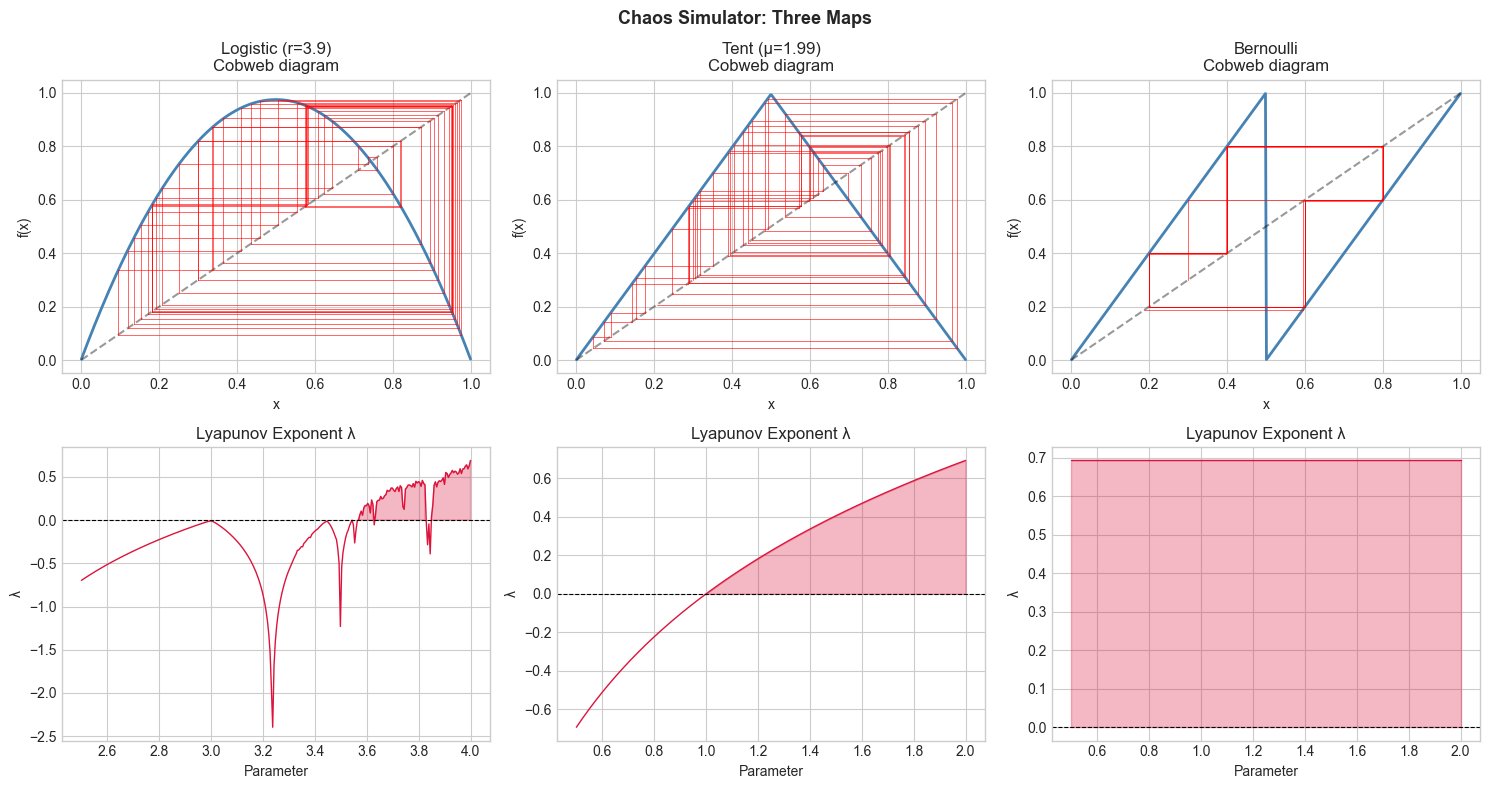

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Three chaotic maps
def logistic(x, r=3.9): return r*x*(1-x)
def tent(x, mu=1.99):   return mu*x if x < 0.5 else mu*(1-x)
def bernoulli(x):        return (2*x) % 1  # exact chaos: Lyapunov = ln(2)

x = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (name, fn, deriv_fn) in enumerate([
    ('Logistic (r=3.9)', logistic, lambda x: 3.9*(1-2*x)),
    ('Tent (μ=1.99)',    tent,     lambda x: np.where(x < 0.5, 1.99, -1.99)),
    ('Bernoulli',        bernoulli, lambda x: 2*np.ones_like(x)),
]):
    # Cobweb
    ax = axes[0, col]
    ax.plot(x, [fn(xi) for xi in x], color='steelblue', linewidth=2)
    ax.plot(x, x, 'k--', alpha=0.4)
    xi = 0.3
    for _ in range(50):
        yi = fn(xi)
        ax.plot([xi, xi], [xi, yi], 'r-', linewidth=0.7, alpha=0.6)
        ax.plot([xi, yi], [yi, yi], 'r-', linewidth=0.7, alpha=0.6)
        xi = yi
    ax.set_title(f'{name}\nCobweb diagram'); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    
    # Lyapunov
    ax = axes[1, col]
    r_vals = np.linspace(0.5, 2.0, 300) if 'Tent' in name or 'Bern' in name else np.linspace(2.5, 4.0, 300)
    lyap = []
    for r_try in r_vals:
        if 'Logistic' in name:
            fn_r = lambda x, r=r_try: r*x*(1-x)
            df_r = lambda x, r=r_try: r*(1-2*x)
        elif 'Tent' in name:
            fn_r = lambda x, r=r_try: r*x if x<0.5 else r*(1-x)
            df_r = lambda x, r=r_try: np.where(x<0.5, r, -r)
        else:
            fn_r = bernoulli
            df_r = lambda x: np.full_like(x, 2.0)
        
        xi = 0.3
        lam = 0
        for i in range(300):
            xi = fn_r(xi)
            d = abs(df_r(xi))
            lam += np.log(d) if d > 0 else -10
        lyap.append(lam / 300)
    
    ax.plot(r_vals, lyap, color='crimson', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.fill_between(r_vals, lyap, 0, where=np.array(lyap) > 0, alpha=0.3, color='crimson')
    ax.set_title(f'Lyapunov Exponent λ'); ax.set_xlabel('Parameter'); ax.set_ylabel('λ')

plt.suptitle('Chaos Simulator: Three Maps', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 2 — Lorenz Attractor (continuous)

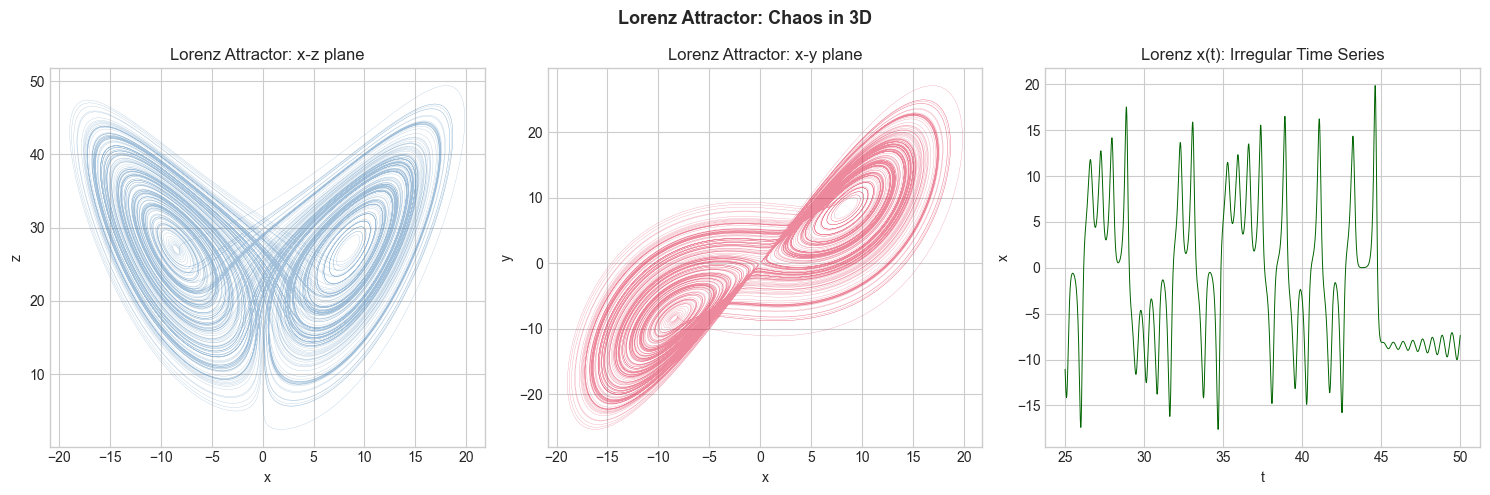

In [2]:
# Lorenz system: the canonical continuous chaotic system
# dx/dt = σ(y-x), dy/dt = x(ρ-z)-y, dz/dt = xy - βz

def lorenz_euler(sigma=10, rho=28, beta=8/3, n_steps=50000, dt=0.005):
    x, y, z = 0.1, 0, 0
    xs, ys, zs = [x], [y], [z]
    for _ in range(n_steps):
        dx = sigma * (y - x) * dt
        dy = (x * (rho - z) - y) * dt
        dz = (x * y - beta * z) * dt
        x += dx; y += dy; z += dz
        xs.append(x); ys.append(y); zs.append(z)
    return np.array(xs), np.array(ys), np.array(zs)

x, y, z = lorenz_euler()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x[5000:], z[5000:], 'steelblue', linewidth=0.2, alpha=0.5)
axes[0].set_title('Lorenz Attractor: x-z plane'); axes[0].set_xlabel('x'); axes[0].set_ylabel('z')

axes[1].plot(x[5000:], y[5000:], 'crimson', linewidth=0.2, alpha=0.5)
axes[1].set_title('Lorenz Attractor: x-y plane'); axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

t = np.arange(len(x)) * 0.005
axes[2].plot(t[5000:10000], x[5000:10000], 'darkgreen', linewidth=0.7)
axes[2].set_title('Lorenz x(t): Irregular Time Series'); axes[2].set_xlabel('t'); axes[2].set_ylabel('x')

plt.suptitle('Lorenz Attractor: Chaos in 3D', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 3 — Sensitive Dependence Summary

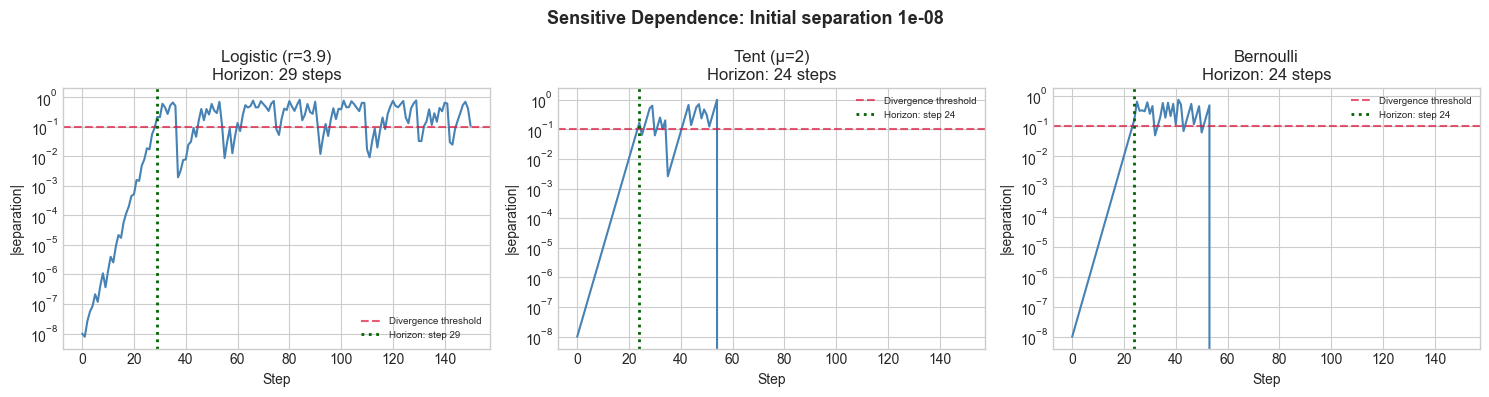

In [3]:
# Show prediction horizons across all three maps
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def logistic(x): return 3.9*x*(1-x)
def tent(x): return 2*x if x < 0.5 else 2*(1-x)
def bernoulli(x): return (2*x) % 1

maps = {'Logistic (r=3.9)': logistic, 'Tent (μ=2)': tent, 'Bernoulli': bernoulli}
DELTA = 1e-8
N = 150
x0 = 0.4

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, fn) in zip(axes, maps.items()):
    x_a = x0
    x_b = x0 + DELTA
    diffs = [DELTA]
    for _ in range(N):
        x_a = fn(x_a)
        x_b = fn(x_b)
        diffs.append(abs(x_a - x_b))
    
    ax.semilogy(diffs, color='steelblue', linewidth=1.5)
    ax.axhline(0.1, color='crimson', linestyle='--', alpha=0.7, label='Divergence threshold')
    horizon = next((i for i, d in enumerate(diffs) if d > 0.1), N)
    ax.axvline(horizon, color='darkgreen', linestyle=':', linewidth=2, label=f'Horizon: step {horizon}')
    ax.set_title(f'{name}\nHorizon: {horizon} steps'); ax.set_xlabel('Step'); ax.set_ylabel('|separation|')
    ax.legend(fontsize=7)

plt.suptitle(f'Sensitive Dependence: Initial separation {DELTA}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Multi-map chaos analysis (logistic, tent, Bernoulli), Lorenz attractor visualization, and prediction horizon comparison.

**Math used:** Lyapunov exponents (ch077), iterative maps (ch076), ODE simulation (ch078), parameter sensitivity (ch069).

**Extensions:** 1) Implement the Hénon map and compute its strange attractor. 2) Compute the fractal dimension of the Lorenz attractor. 3) Implement chaos control: tiny perturbations that stabilize a periodic orbit.